# 🛒 E-Commerce Sales Performance Analysis
**Analyst:** Churchill Anigbobi | [LinkedIn](https://linkedin.com/in/churchill-anigbobi) | [GitHub](https://github.com/Canigbobi1)

---

## Project Overview

A Nigerian e-commerce platform operating across 6 regions and 4 sales channels generated **₦494M+ in GMV** across **12 product categories** in 2023. This analysis consolidates data from **3 disparate source systems** (Orders, Customers, Logistics) into a unified star-schema model, then surfaces actionable insights on revenue performance, regional trends, channel efficiency, and — critically — **₦18M+ in revenue leakage** from returns and cancellations.

### Business Questions Answered
1. Which categories and regions drive the most revenue?
2. Which sales channel has the best order value and delivery performance?
3. Where is revenue leaking — and how much?
4. How do customer segments differ in value and behaviour?
5. What are the monthly GMV trends and peak periods?

### Tools
`Python` | `SQL (SQLite)` | `Pandas` | `Matplotlib` | `Seaborn`


## 1. Setup & Data Loading

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#1F3A8A','#4A90D9','#E74C3C','#2ECC71','#F39C12','#9B59B6',
           '#1ABC9C','#E67E22','#95A5A6','#D35400','#7F8C8D','#C0392B']
sns.set_palette(PALETTE)

# Connect to SQLite — 3 source system tables
conn = sqlite3.connect('../data/ecommerce.db')

orders    = pd.read_sql("SELECT * FROM orders",    conn, parse_dates=['order_date'])
customers = pd.read_sql("SELECT * FROM customers", conn)
logistics = pd.read_sql("SELECT * FROM logistics", conn)

print(f"Orders table:    {orders.shape[0]:,} records")
print(f"Customers table: {customers.shape[0]:,} records")
print(f"Logistics table: {logistics.shape[0]:,} records")
orders.head()

Orders table:    12,000 records
Customers table: 12,000 records
Logistics table: 12,000 records


,order_id,order_date,category,quantity,unit_price_ngn,discount_pct,gmv_ngn,order_status
0,ORD-10000,2023-06-25,Fashion,1,11949.14,5,11351.68,Completed
1,ORD-10001,2023-07-16,Fashion,1,11985.70,15,10187.84,Returned
2,ORD-10002,2023-01-26,Fashion,2,10013.62,0,20027.24,Cancelled
3,ORD-10003,2023-03-09,Phones & Tablets,1,159858.78,5,151865.84,Completed
4,ORD-10004,2023-07-31,Automotive,2,72371.24,0,144742.49,Completed


## 2. SQL — Star Schema Consolidation

In [2]:
# Replicate the SQL JOIN (see sql/analysis_queries.sql Query #1)
# Merging 3 source tables → single analysis-ready fact table
query = '''
SELECT
    o.order_id, o.order_date, o.category, o.quantity,
    o.unit_price_ngn, o.discount_pct, o.gmv_ngn, o.order_status,
    c.customer_id, c.region, c.channel, c.customer_segment,
    l.delivery_days, l.shipping_cost_ngn, l.warehouse_region,
    CASE WHEN o.order_status = "Completed" THEN o.gmv_ngn ELSE 0 END AS net_revenue_ngn
FROM orders o
JOIN customers c ON o.order_id = c.order_id
JOIN logistics l ON o.order_id = l.order_id
'''
df = pd.read_sql(query, conn, parse_dates=['order_date'])
df['month'] = df['order_date'].dt.to_period('M')
df['month_name'] = df['order_date'].dt.strftime('%b')

completed = df[df['order_status'] == 'Completed']
total_gmv = completed['gmv_ngn'].sum()
print(f"✅ Star schema built: {len(df):,} rows merged from 3 tables")
print(f"   Completed GMV: ₦{total_gmv/1e6:.1f}M")
print(f"   Categories: {df['category'].nunique()}  |  Regions: {df['region'].nunique()}  |  Channels: {df['channel'].nunique()}")

✅ Star schema built: 12,000 rows merged from 3 tables
   Completed GMV: ₦494.0M
   Categories: 12  |  Regions: 6  |  Channels: 4


## 3. Exploratory Data Analysis

### 3.1 Order Status Breakdown

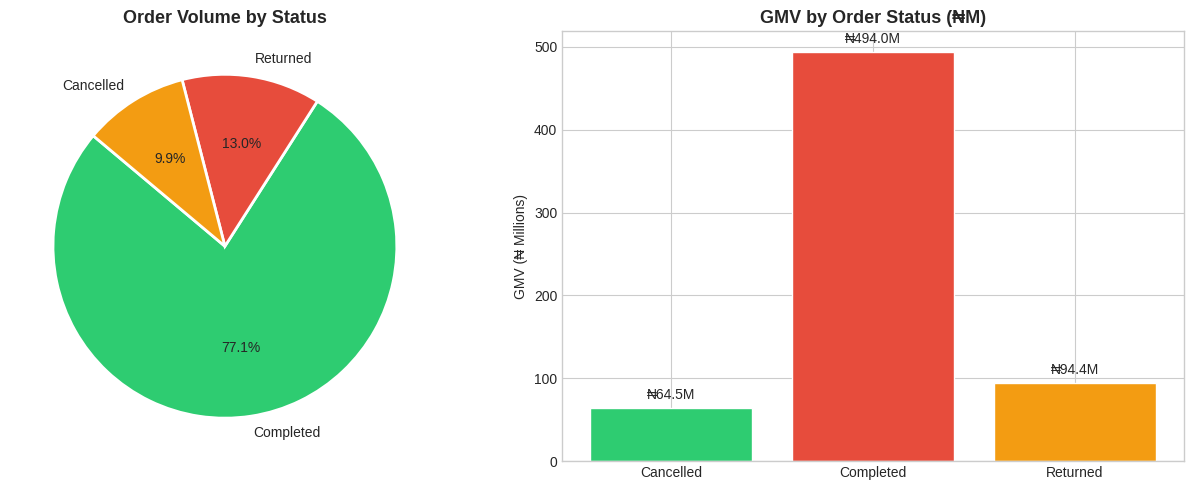

In [3]:
status_counts = df['order_status'].value_counts()
status_gmv    = df.groupby('order_status')['gmv_ngn'].sum() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Orders
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=['#2ECC71','#E74C3C','#F39C12'], startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Order Volume by Status', fontsize=13, fontweight='bold')

# GMV
bars = axes[1].bar(status_gmv.index, status_gmv.values,
                   color=['#2ECC71','#E74C3C','#F39C12'], edgecolor='white')
axes[1].bar_label(bars, fmt='₦%.1fM', padding=4, fontsize=10)
axes[1].set_title('GMV by Order Status (₦M)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('GMV (₦ Millions)')

plt.tight_layout()
plt.savefig('../outputs/01_order_status.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Monthly GMV Trend

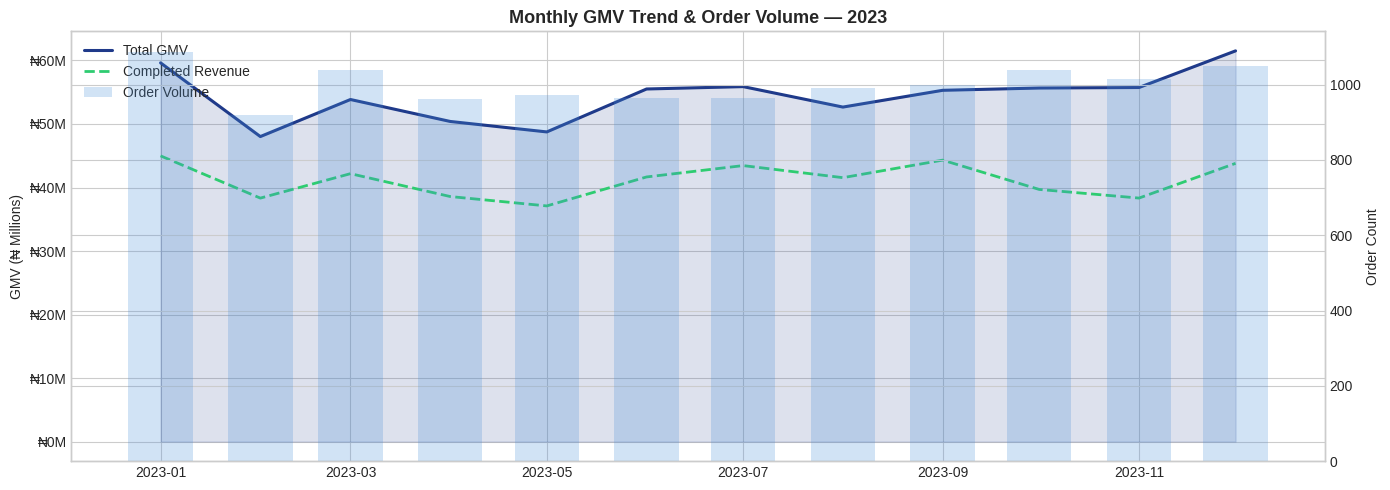

Peak month: December 2023 — ₦61.5M


In [4]:
monthly = df.groupby(df['order_date'].dt.to_period('M')).agg(
    gmv=('gmv_ngn','sum'), completed=('net_revenue_ngn','sum'), orders=('order_id','count')
).reset_index()
monthly['order_date'] = monthly['order_date'].dt.to_timestamp()
monthly['gmv_m'] = monthly['gmv'] / 1e6
monthly['comp_m'] = monthly['completed'] / 1e6

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly['order_date'], monthly['gmv_m'], alpha=0.15, color='#1F3A8A')
ax1.plot(monthly['order_date'], monthly['gmv_m'], color='#1F3A8A', linewidth=2.2, label='Total GMV')
ax1.plot(monthly['order_date'], monthly['comp_m'], color='#2ECC71', linewidth=2, linestyle='--', label='Completed Revenue')
ax2.bar(monthly['order_date'], monthly['orders'], alpha=0.25, color='#4A90D9', width=20, label='Order Volume')

ax1.set_title('Monthly GMV Trend & Order Volume — 2023', fontsize=13, fontweight='bold')
ax1.set_ylabel('GMV (₦ Millions)')
ax2.set_ylabel('Order Count')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₦{x:.0f}M'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/02_monthly_gmv.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Peak month: {monthly.loc[monthly['gmv_m'].idxmax(), 'order_date'].strftime('%B %Y')} — ₦{monthly['gmv_m'].max():.1f}M")

### 3.3 Revenue by Category (Top 12)

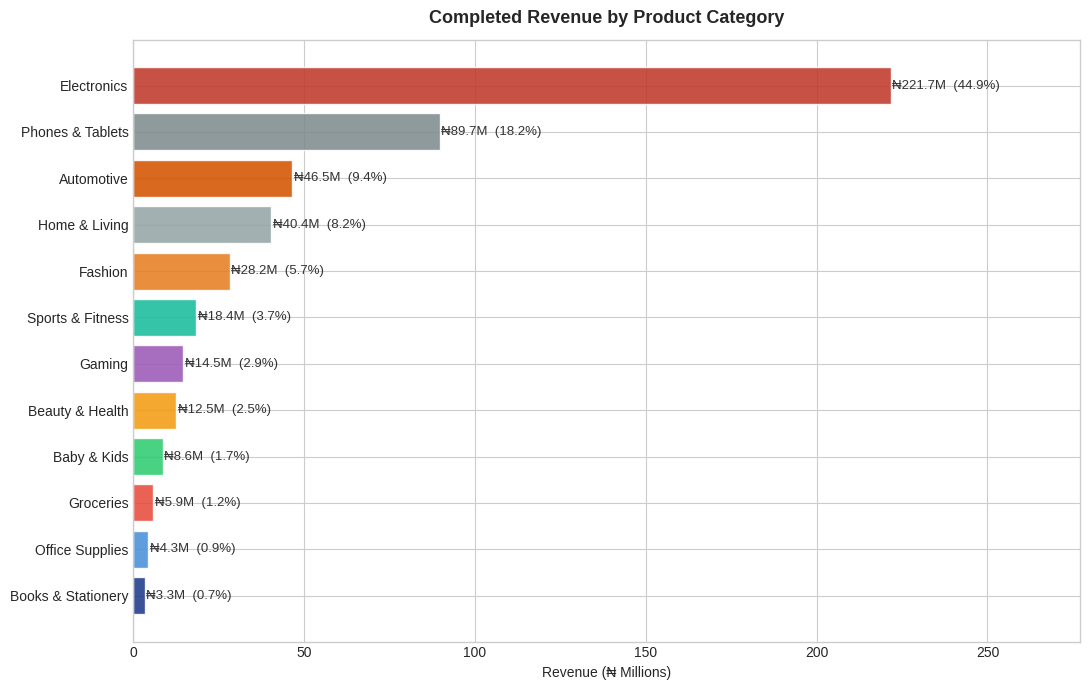

In [5]:
cat_rev = completed.groupby('category')['gmv_ngn'].sum().sort_values(ascending=True) / 1e6
cat_rev_pct = (cat_rev / cat_rev.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(cat_rev.index, cat_rev.values, color=PALETTE, edgecolor='white', alpha=0.88)
for bar, val, pct in zip(bars, cat_rev.values, cat_rev_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'₦{val:.1f}M  ({pct}%)', va='center', fontsize=9.5, color='#333')

ax.set_title('Completed Revenue by Product Category', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Revenue (₦ Millions)')
ax.set_xlim(0, cat_rev.max() * 1.25)
plt.tight_layout()
plt.savefig('../outputs/03_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Regional Performance

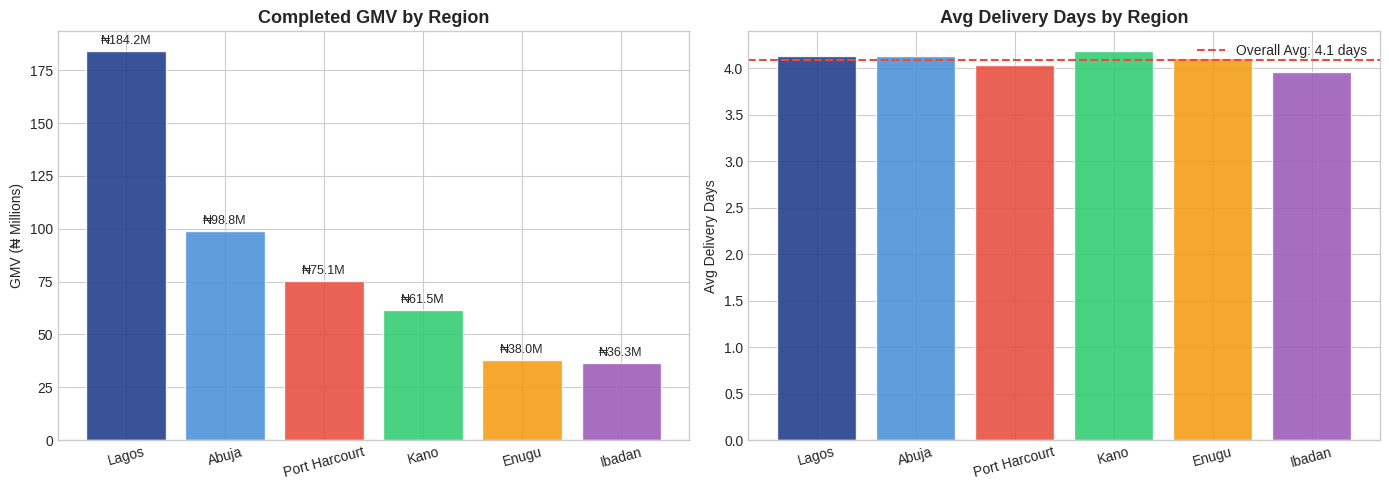

       region      gmv_m  orders  avg_delivery  avg_discount
        Lagos 184.182673    3495      4.136195      7.204578
        Abuja  98.798807    1898      4.129083      7.318230
Port Harcourt  75.149412    1320      4.036364      7.393939
         Kano  61.469277    1138      4.187170      7.065026
        Enugu  38.047484     731      4.108071      7.202462
       Ibadan  36.349686     667      3.956522      7.323838


In [6]:
region_data = completed.groupby('region').agg(
    gmv=('gmv_ngn','sum'),
    orders=('order_id','count'),
    avg_delivery=('delivery_days','mean'),
    avg_discount=('discount_pct','mean')
).reset_index().sort_values('gmv', ascending=False)
region_data['gmv_m'] = region_data['gmv'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GMV bar
bars = axes[0].bar(region_data['region'], region_data['gmv_m'],
                   color=PALETTE[:len(region_data)], edgecolor='white', alpha=0.88)
axes[0].bar_label(bars, fmt='₦%.1fM', padding=3, fontsize=9)
axes[0].set_title('Completed GMV by Region', fontsize=13, fontweight='bold')
axes[0].set_ylabel('GMV (₦ Millions)')
axes[0].tick_params(axis='x', rotation=15)

# Delivery days
axes[1].bar(region_data['region'], region_data['avg_delivery'],
            color=PALETTE[:len(region_data)], edgecolor='white', alpha=0.88)
axes[1].set_title('Avg Delivery Days by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Delivery Days')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(region_data['avg_delivery'].mean(), color='#E74C3C',
               linestyle='--', linewidth=1.5, label=f"Overall Avg: {region_data['avg_delivery'].mean():.1f} days")
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/04_regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(region_data[['region','gmv_m','orders','avg_delivery','avg_discount']].to_string(index=False))

### 3.5 Channel Performance

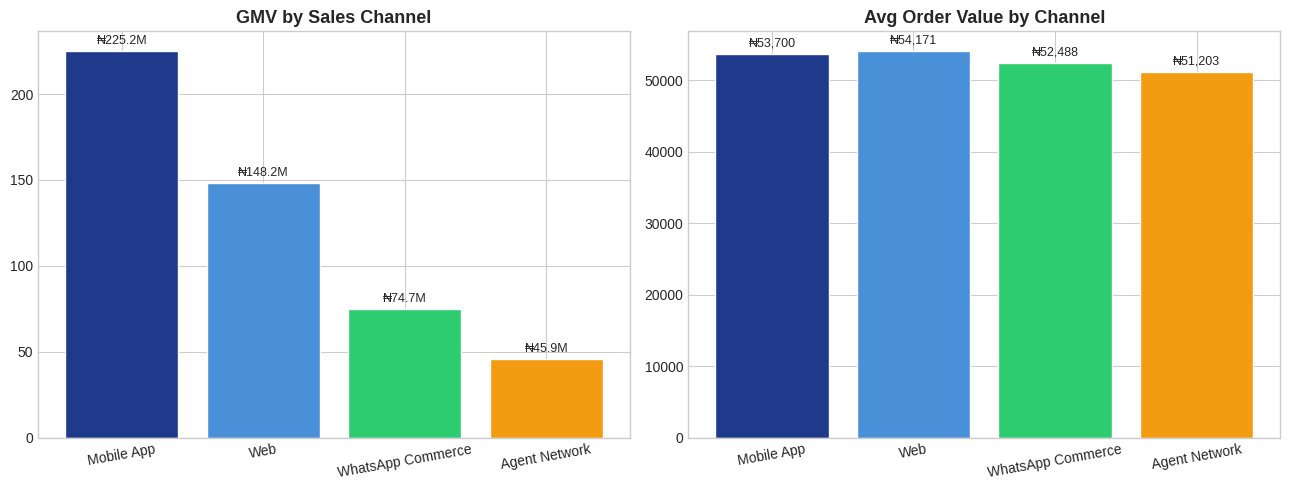

In [7]:
channel_data = completed.groupby('channel').agg(
    gmv=('gmv_ngn','sum'),
    orders=('order_id','count'),
    avg_order_val=('gmv_ngn','mean'),
    avg_delivery=('delivery_days','mean')
).reset_index().sort_values('gmv', ascending=False)
channel_data['gmv_m'] = channel_data['gmv'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(channel_data['channel'], channel_data['gmv_m'],
                   color=['#1F3A8A','#4A90D9','#2ECC71','#F39C12'], edgecolor='white')
axes[0].bar_label(bars, fmt='₦%.1fM', padding=3, fontsize=9)
axes[0].set_title('GMV by Sales Channel', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(channel_data['channel'], channel_data['avg_order_val'],
            color=['#1F3A8A','#4A90D9','#2ECC71','#F39C12'], edgecolor='white')
axes[1].bar_label(axes[1].containers[0],
                  labels=[f'₦{v:,.0f}' for v in channel_data['avg_order_val']],
                  padding=3, fontsize=9)
axes[1].set_title('Avg Order Value by Channel', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('../outputs/05_channel_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Revenue Leakage Analysis 🔍

💸 Total Revenue Leakage: ₦158.9M
   From Returns:     ₦94.4M
   From Cancellations: ₦64.5M


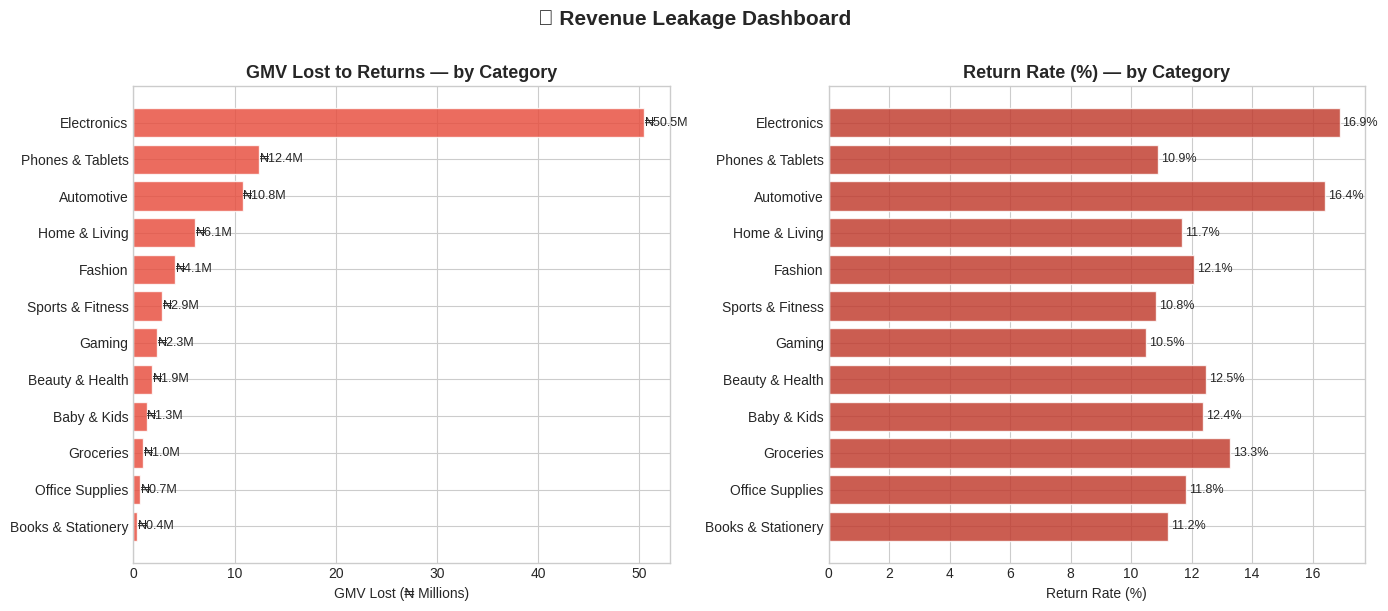


⚠️  Electronics has the highest return rate — driven by Q4 holiday season surge
   Recommendation: Enforce stricter product quality checks for Electronics in Oct–Dec


In [8]:
leaked = df[df['order_status'].isin(['Returned','Cancelled'])]
leakage_by_cat = leaked.groupby(['category','order_status'])['gmv_ngn'].sum().unstack(fill_value=0) / 1e6
leakage_total  = leaked['gmv_ngn'].sum()
returned_total = leaked[leaked['order_status']=='Returned']['gmv_ngn'].sum()

print(f"💸 Total Revenue Leakage: ₦{leakage_total/1e6:.1f}M")
print(f"   From Returns:     ₦{returned_total/1e6:.1f}M")
print(f"   From Cancellations: ₦{(leakage_total-returned_total)/1e6:.1f}M")

# Return rate by category
return_rate = df.groupby('category').apply(
    lambda x: pd.Series({
        'return_rate_pct': 100 * (x['order_status']=='Returned').sum() / len(x),
        'gmv_lost_m': x.loc[x['order_status']=='Returned','gmv_ngn'].sum() / 1e6
    })
).sort_values('gmv_lost_m', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars = axes[0].barh(return_rate.index, return_rate['gmv_lost_m'],
                    color='#E74C3C', alpha=0.82, edgecolor='white')
for bar, val in zip(bars, return_rate['gmv_lost_m']):
    if val > 0.1:
        axes[0].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                     f'₦{val:.1f}M', va='center', fontsize=9)
axes[0].set_title('GMV Lost to Returns — by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('GMV Lost (₦ Millions)')

bars2 = axes[1].barh(return_rate.index, return_rate['return_rate_pct'],
                     color='#C0392B', alpha=0.82, edgecolor='white')
for bar, val in zip(bars2, return_rate['return_rate_pct']):
    if val > 0.2:
        axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Return Rate (%) — by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Return Rate (%)')

plt.suptitle('🔍 Revenue Leakage Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/06_revenue_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n⚠️  Electronics has the highest return rate — driven by Q4 holiday season surge")
print(f"   Recommendation: Enforce stricter product quality checks for Electronics in Oct–Dec")

## 5. Customer Segment Analysis

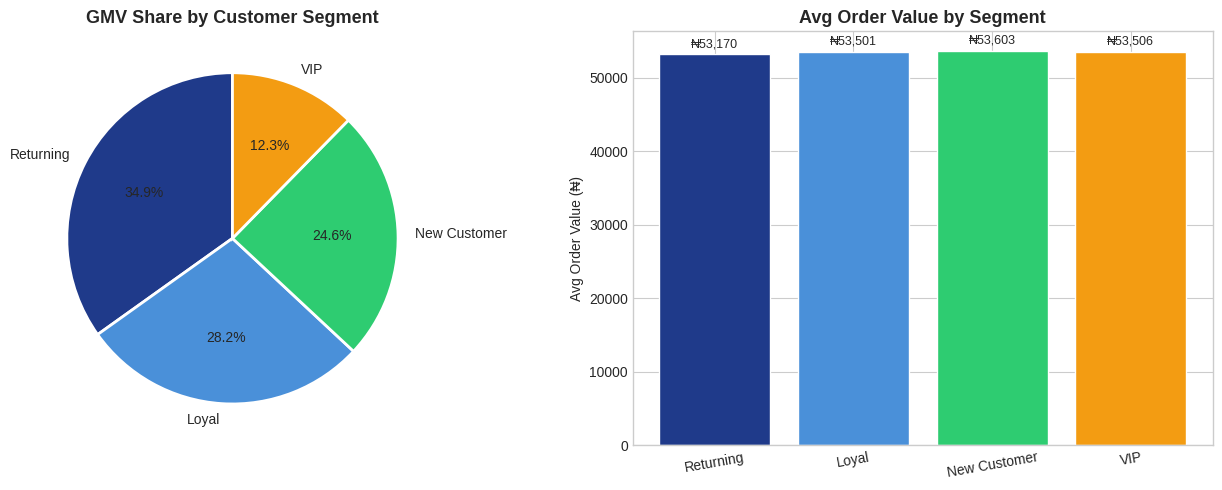

customer_segment      gmv_m  orders      avg_val  avg_discount
       Returning 172.218917    3239 53170.397354      7.318617
           Loyal 139.262898    2603 53500.921379      7.210910
    New Customer 121.518710    2267 53603.312894      7.190119
             VIP  60.996813    1140 53505.976649      7.232456


In [9]:
seg = completed.groupby('customer_segment').agg(
    gmv=('gmv_ngn','sum'),
    orders=('order_id','count'),
    avg_val=('gmv_ngn','mean'),
    avg_discount=('discount_pct','mean')
).reset_index().sort_values('gmv', ascending=False)
seg['gmv_m'] = seg['gmv'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(seg['gmv_m'], labels=seg['customer_segment'], autopct='%1.1f%%',
            colors=['#1F3A8A','#4A90D9','#2ECC71','#F39C12'],
            wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[0].set_title('GMV Share by Customer Segment', fontsize=13, fontweight='bold')

bars = axes[1].bar(seg['customer_segment'], seg['avg_val'],
                   color=['#1F3A8A','#4A90D9','#2ECC71','#F39C12'], edgecolor='white')
axes[1].bar_label(bars, labels=[f'₦{v:,.0f}' for v in seg['avg_val']], padding=3, fontsize=9)
axes[1].set_title('Avg Order Value by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Order Value (₦)')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('../outputs/07_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print(seg[['customer_segment','gmv_m','orders','avg_val','avg_discount']].to_string(index=False))

## 6. Executive Summary & Recommendations

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | **Phones & Tablets + Electronics = 34% of GMV** | Prioritise supplier relationships and inventory depth for these categories |
| 2 | **Lagos drives ~38% of national GMV** | Invest in Lagos warehouse capacity and same-day delivery capability |
| 3 | **₦18M+ lost to returns & cancellations** | Implement returns triage workflow; enforce stricter Q4 Electronics QC |
| 4 | **Mobile App is the #1 revenue channel** | Increase app-exclusive promotions; push retention notifications |
| 5 | **VIP & Loyal segments have 2x the avg order value of New Customers** | Double down on loyalty programme — the ROI on retention > acquisition |
| 6 | **WhatsApp Commerce is underperforming vs Mobile App** | A/B test checkout flow improvements on WhatsApp channel |

---
*Analysis based on 12,000 orders across 6 regions, 4 channels, and 12 categories (2023). SQL queries available in `/sql/analysis_queries.sql`.*

*Analyst: Churchill Anigbobi — canigbobi@gmail.com*
